In [1]:
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, confusion_matrix,classification_report)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import  PolynomialFeatures

# Task-1

## Part A: Load Dataset & Data Cleaning

In [2]:
df = pd.read_csv('/home/shlok/College/SemIV/FCSP2/03-machine-learning/DATA/house_price_analysis.csv')

In [3]:
print(df.head())

   Area  Bedrooms  Bathrooms  Age  Parking  LocationScore    Price
0   900         2          1   10        1              6  3200000
1  1100         2          2    8        1              7  4200000
2  1400         3          2    6        1              8  5500000
3  1600         3          3    5        2              9  6800000
4  1800         4          3    4        2              9  7600000


In [4]:
print("Null Values: ",df.isnull().sum().sum())

Null Values:  0


In [5]:
print(df.columns)

Index(['Area', 'Bedrooms', 'Bathrooms', 'Age', 'Parking', 'LocationScore',
       'Price'],
      dtype='object')


In [6]:
print("Duplicate Rows: ",df.duplicated().sum())

Duplicate Rows:  0


In [7]:
print(df.describe())

              Area   Bedrooms  Bathrooms       Age    Parking  LocationScore  \
count    15.000000  15.000000  15.000000  15.00000  15.000000       15.00000   
mean   1463.333333   3.133333   2.400000   5.80000   1.666667        8.00000   
std     374.388390   0.915475   0.985611   3.27763   0.723747        1.36277   
min     900.000000   2.000000   1.000000   1.00000   1.000000        6.00000   
25%    1175.000000   2.500000   2.000000   3.50000   1.000000        7.00000   
50%    1500.000000   3.000000   2.000000   5.00000   2.000000        8.00000   
75%    1725.000000   4.000000   3.000000   7.50000   2.000000        9.00000   
max    2100.000000   5.000000   4.000000  12.00000   3.000000       10.00000   

              Price  
count  1.500000e+01  
mean   6.033333e+06  
std    2.047530e+06  
min    3.200000e+06  
25%    4.550000e+06  
50%    6.100000e+06  
75%    7.400000e+06  
max    9.800000e+06  


## Part B: Data Visualization 

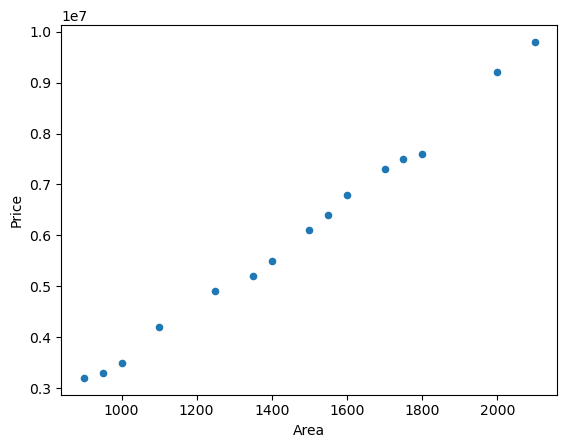

In [8]:
df.plot.scatter(x='Area',y='Price')
plt.show()

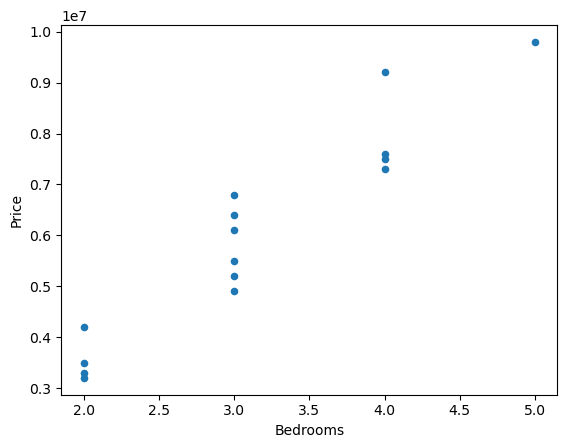

In [9]:
df.plot.scatter(x='Bedrooms',y='Price')
plt.show()

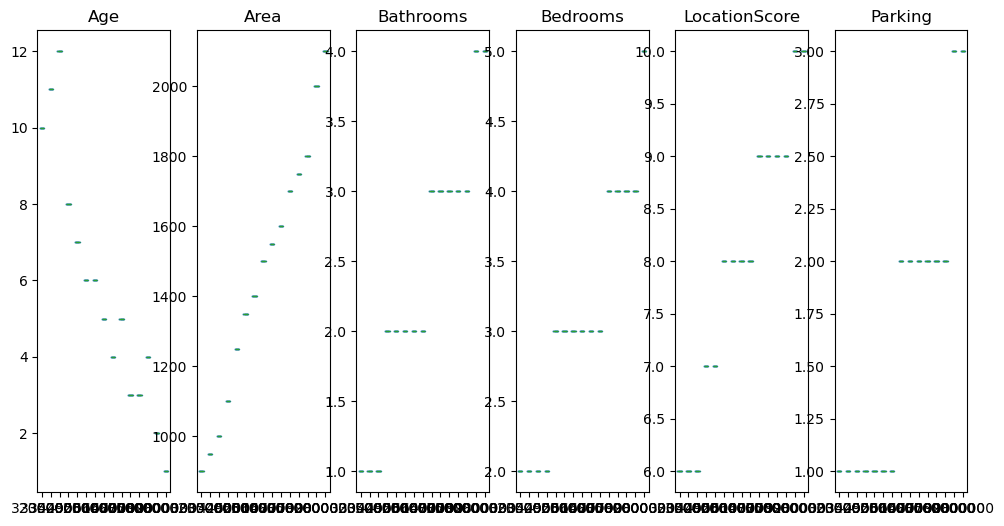

In [10]:
df.plot.box(by='Price',figsize=(12,6))
plt.show()

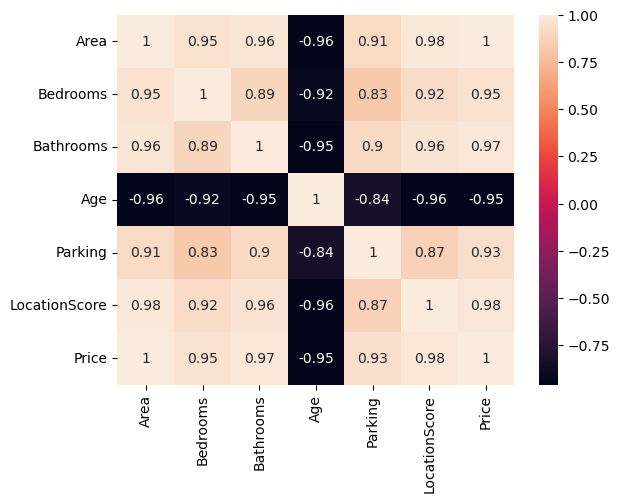

In [11]:
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix,annot=True)
plt.show()

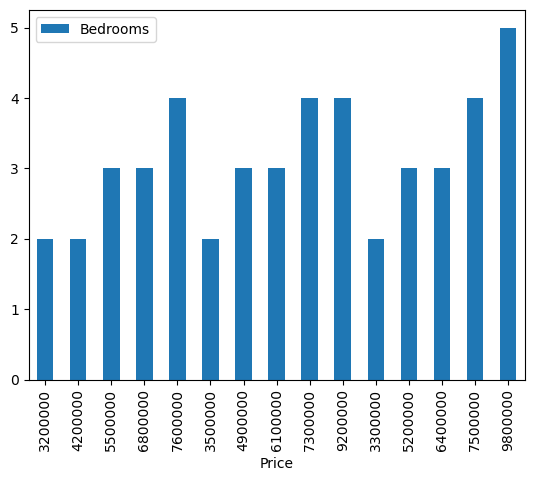

In [12]:
df.plot.bar(x='Price',y='Bedrooms')
plt.show()

## Part C: Regression Models

X Train: (12, 1)  Y Train: (12,)
X Test: (3, 1)  Y Test: (3,)
Accuracy: 99.0647655124907
Mean Squared Error: 58192368111.69043
Model Intercept: -1942737.4301675977
Model Coeff: [5435.75418994]


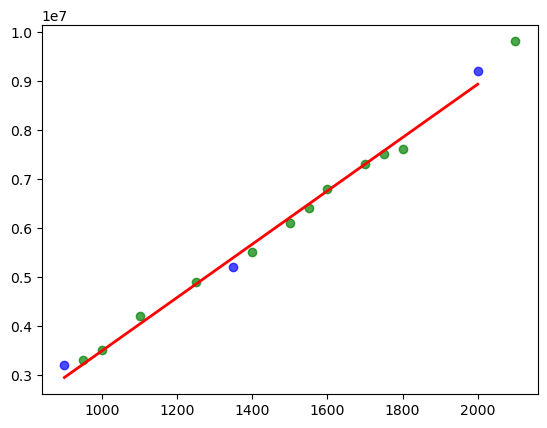

In [13]:
x = df[['Area']]
y= df['Price']

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

print("X Train:",x_train.shape," Y Train:",y_train.shape)
print("X Test:",x_test.shape," Y Test:",y_test.shape)


model = LinearRegression()
model.fit(x_train,y_train)
pre = model.predict(x_test)

acc = r2_score(y_test,pre)
mse = mean_squared_error(y_test,pre)
print("Accuracy:",acc*100)
print("Mean Squared Error:",mse)
print("Model Intercept:",model.intercept_)
print("Model Coeff:",model.coef_)


plt.scatter(x_train, y_train, color='green', label='Actual', alpha=0.7)
plt.scatter(x_test, y_test, color='blue', label='Actual', alpha=0.7)
plt.plot(x_test,pre, color='red', linewidth=2, label='Predicted')
plt.show()

In [14]:
x = df.drop(columns=['Price'],axis=1)
y= df['Price']

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

print("X Train:",x_train.shape," Y Train:",y_train.shape)
print("X Test:",x_test.shape," Y Test:",y_test.shape)


model = LinearRegression()
model.fit(x_train,y_train)
pre = model.predict(x_test)

acc = r2_score(y_test,pre)
mse = mean_squared_error(y_test,pre)
print("Accuracy:",acc*100)
print("Mean Squared Error:",mse)
print("Model Intercept:",model.intercept_)
print("Model Coeff:",model.coef_)

X Train: (12, 6)  Y Train: (12,)
X Test: (3, 6)  Y Test: (3,)
Accuracy: 99.81179806604561
Mean Squared Error: 11710342557.161772
Model Intercept: -2126636.904761901
Model Coeff: [  2279.76190476 430505.95238095 302827.38095238  29613.09523809
 439880.95238095 230059.52380952]


In [15]:
x = df[['Area']]
y = df['Price']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


poly = PolynomialFeatures(degree=3, include_bias=False) # Degree 3
x_train_poly = poly.fit_transform(x_train) # 'fit_transform'
x_test_poly = poly.transform(x_test) # Use .transform() on test data

model = LinearRegression()
model.fit(x_train_poly, y_train)

pre = model.predict(x_test_poly)

acc = r2_score(y_test, pre)
mse = mean_squared_error(y_test, pre)

print("Accuracy (R2 Score):", acc * 100)
print("Mean Squared Error:", mse)
print("Model Intercept:",model.intercept_)
print("Model Coeff:",model.coef_)

Accuracy (R2 Score): 99.4479351805577
Mean Squared Error: 34350699876.408752
Model Intercept: -5461806.945108216
Model Coeff: [ 1.40711249e+04 -6.67740524e+00  1.63519674e-03]


## Part D: Classification Models

In [16]:
df['Target_Hot'] = np.where(df['Price']>df['Price'].median(),1,0)

In [17]:
x=df.drop("Target_Hot",axis=1)
y=df["Target_Hot"]

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)
model=KNeighborsClassifier(n_neighbors=3)
model.fit(x_train,y_train)
pre=model.predict(x_test)
acc=accuracy_score(y_test,pre)
print(acc*100)
class_report = classification_report(y_test,pre)
print(class_report)
print(confusion_matrix(y_test,pre))

100.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         2

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5

[[3 0]
 [0 2]]


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
x=df.drop(["Price","Target_Hot"],axis=1)
y=df["Target_Hot"]

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)
model=DecisionTreeClassifier(criterion="entropy",max_depth=3)
model.fit(x_train,y_train)
pre=model.predict(x_test)
acc=accuracy_score(y_test,pre)
print(acc*100)

class_report = classification_report(y_test,pre)
print(class_report)
print(confusion_matrix(y_test,pre))

100.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         2

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5

[[3 0]
 [0 2]]


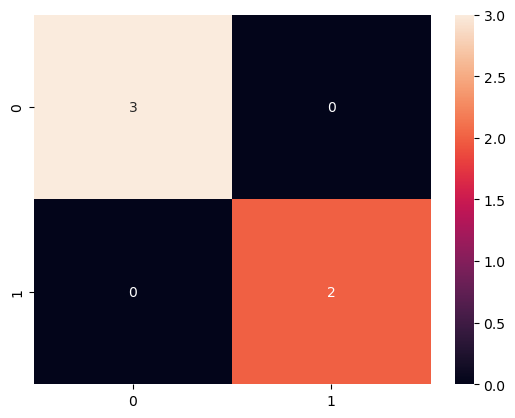

In [19]:
sns.heatmap(confusion_matrix(y_test,pre),annot=True)
plt.show()

In [31]:
import pandas as pd
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.model_selection import train_test_split
import seaborn as sns

In [ ]:
df = pd.read_csv('/home/shlok/College/SemIV/FCSP2/03-machine-learning/DATA/DATASET/diabetes.csv')
x = df.drop(columns=['Outcome'],axis=1)
y = df['Outcome']

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

model = SVC(kernel='rbf',C=1)
model.fit(x_train,y_train)
pre = model.predict(x_test)
acc = accuracy_score(y_test,pre)

print(acc*100)

76.62337662337663


62.5


<Axes: >

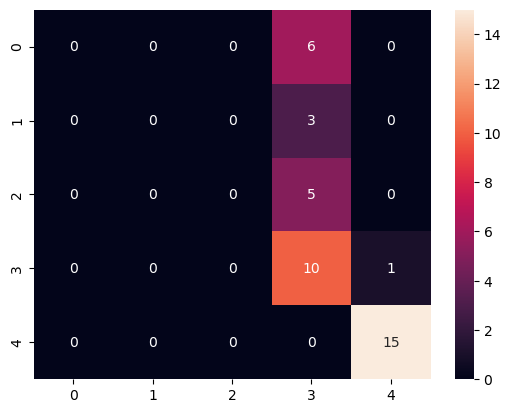

In [34]:
df = pd.read_csv('/home/shlok/College/SemIV/FCSP2/03-machine-learning/DATA/DATASET/Datasets/drug200.csv')
x = df.drop(columns=['Drug'],axis=1)
x = pd.get_dummies(x)
y = df['Drug']

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

model = SVC(kernel='rbf',C=1)
model.fit(x_train,y_train)
pre = model.predict(x_test)
acc = accuracy_score(y_test,pre)

print(acc*100)

cf = confusion_matrix(y_test,pre)

sns.heatmap(cf,annot=True)


Accuracy: 94.74%


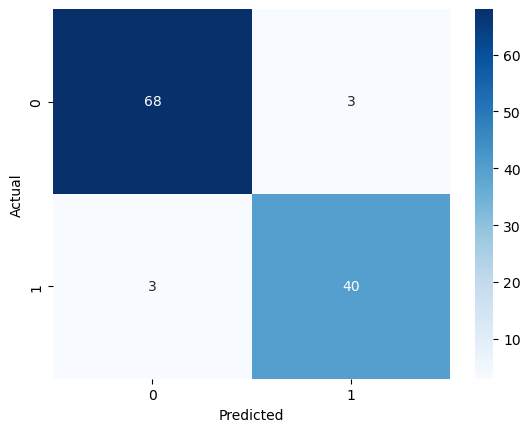

In [44]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Load and clean data
df = pd.read_csv('/home/shlok/College/SemIV/FCSP2/03-machine-learning/DATA/DATASET/Datasets/cancer.csv')
df.drop(columns=['Unnamed: 32', 'id'], inplace=True, errors='ignore')

# Features and Target
X = df.drop(columns=['diagnosis'],axis=1)
y = df['diagnosis']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model Training
model = RandomForestClassifier(n_estimators=5,random_state=42)
model.fit(X_train, y_train)

# Evaluation
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Visualization
cf = confusion_matrix(y_test, y_pred)
sns.heatmap(cf, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()



In [46]:
from sklearn.neighbors import KNeighborsClassifier
df = pd.read_csv("/home/shlok/College/SemIV/FCSP2/03-machine-learning/DATA/DATASET/Datasets/drug200.csv")
x = df.drop(labels=["Drug"],axis=1)
x = pd.get_dummies(x)
y = df["Drug"]
xtrain,xtest,ytrain,ytest = train_test_split(x,y,test_size=0.2,random_state=42)
accs = []
models = {RandomForestClassifier(n_estimators=10,criterion="entropy",max_depth=4):"Random Forest Classifier",SVC(kernel="rbf",C=3):"SVC",KNeighborsClassifier(n_neighbors=5):"KNeighbours Classifier"}
for i in models.keys():
    model = i
    model.fit(xtrain,ytrain)
    pre = model.predict(xtest)
    acc = accuracy_score(ytest,pre)
    # cm = confusion_matrix(ytest,pre)
    accs.append({models[i]:acc})
print(accs)
# sns.heatmap(data=accs,annot=True)

[{'Random Forest Classifier': 1.0}, {'SVC': 0.65}, {'KNeighbours Classifier': 0.675}]
